# Отклик на кредитный оффер

Нужно оценить вероятность, что клиент примет предложенный кредитный оффер.  
Ниже мой рабочий пайплайн: загрузка данных, фичи, time-based validation и несколько бустингов.

In [44]:
!pip -q install lightgbm catboost xgboost scipy

In [45]:
import os
import gc
import warnings

import numpy as np
import pandas as pd

from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

DATA_DIR = '/content'
TRAIN_PATH = os.path.join(DATA_DIR, 'train_apps.csv')
TEST_PATH = os.path.join(DATA_DIR, 'test_apps.csv')
SAMPLE_PATH = os.path.join(DATA_DIR, 'sample_submission.csv')

TARGET = 'target_value'
ID_COL = 'front_id'
DATE_COL = 'decision_day'

RUN_LIGHTGBM = True
RUN_CATBOOST = True
RUN_XGBOOST = True

LGB_SEEDS = [42, 123, 2025, 777, 31415]
CAT_SEEDS = [42]
XGB_SEEDS = [42]

VALID_FROM = '2025-02-01'

In [46]:
train_raw = pd.read_csv(TRAIN_PATH, parse_dates=[DATE_COL])
test_raw = pd.read_csv(TEST_PATH, parse_dates=[DATE_COL])
sample = pd.read_csv(SAMPLE_PATH)

print('train:', train_raw.shape)
print('test :', test_raw.shape)
print('sample:', sample.shape)
print('target mean:', train_raw[TARGET].mean())
print('date train period:', train_raw[DATE_COL].min(), '→', train_raw[DATE_COL].max())
print('date test period:', test_raw[DATE_COL].min(), '→', test_raw[DATE_COL].max())

print('sample ids in test:', sample[ID_COL].isin(test_raw[ID_COL]).sum())
print('sample ids in train:', sample[ID_COL].isin(train_raw[ID_COL]).sum())

train: (145241, 28)
test : (36311, 27)
sample: (45032, 2)
target mean: 0.06090566713255899
date train period: 2024-02-01 00:00:00 → 2025-06-05 00:00:00
date test period: 2025-06-05 00:00:00 → 2025-12-01 00:00:00
sample ids in test: 36311
sample ids in train: 8721


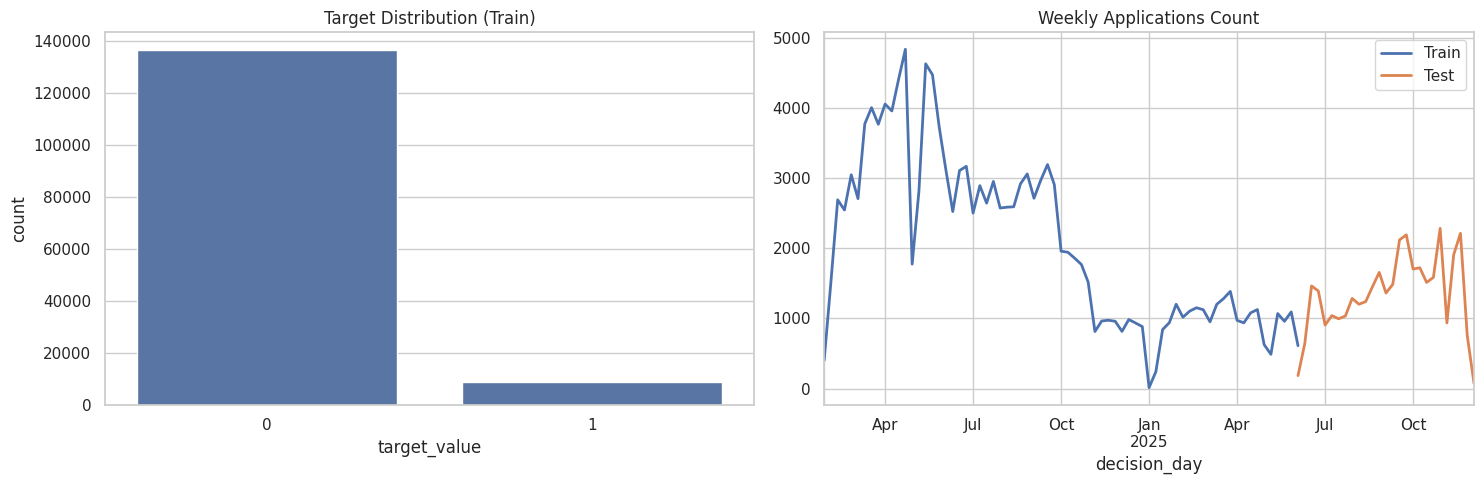

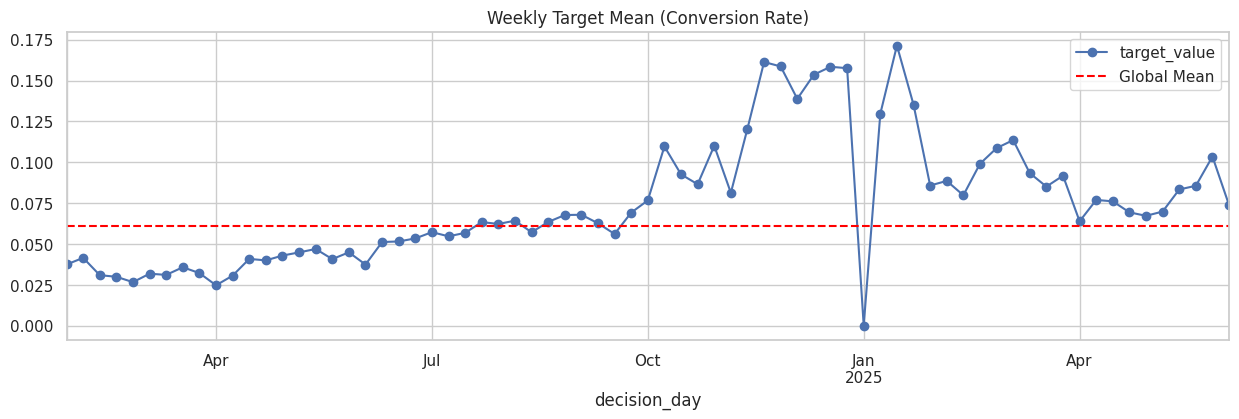

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# 1. Target Distribution
plt.subplot(1, 2, 1)
sns.countplot(x=TARGET, data=train_raw)
plt.title('Target Distribution (Train)')

# 2. Time Series of Applications
plt.subplot(1, 2, 2)
train_raw.set_index(DATE_COL).resample('W').size().plot(label='Train', lw=2)
test_raw.set_index(DATE_COL).resample('W').size().plot(label='Test', lw=2)
plt.title('Weekly Applications Count')
plt.legend()

plt.tight_layout()
plt.show()

# 3. Target mean over time
plt.figure(figsize=(15, 4))
train_raw.set_index(DATE_COL).resample('W')[TARGET].mean().plot(marker='o')
plt.axhline(train_raw[TARGET].mean(), color='red', linestyle='--', label='Global Mean')
plt.title('Weekly Target Mean (Conversion Rate)')
plt.legend()
plt.show()

### Advanced EDA: Feature Relationships and Importance
We will look at how the target behaves relative to key financial features and visualize which features the model finds most useful.

--- Top Drivers of Offer Acceptance (Positive) ---
target_value                       1.000000
loan_rev_max_start_non_fin         0.322518
cnt_cred_loan_90                   0.206632
cnt_deb_loan_90                    0.176924
cnt_deb_ul_ip_90                   0.131116
cnt_deb_ul_ip_30                   0.128847
loan_rev_min_start_fin             0.127418
log_sum_deb_ul_90                  0.122152
sum_deb_ul_90                      0.118331
count_all_corp_dashboard_events    0.117099
Name: target_value, dtype: float64

--- Top Inhibitors of Offer Acceptance (Negative) ---
sum_deb_ul_90_isna                -0.132765
overdraft_app_term_max_360        -0.139311
sum_deb_ul_30_isna                -0.143046
missing_share                     -0.152718
missing_count                     -0.152718
loan_minus_min                    -0.158087
loan_minus_max                    -0.164683
loan_rev_min_start_fin_isna       -0.175526
loan_rev_max_start_non_fin_isna   -0.184292
overdraft_app_term_max_

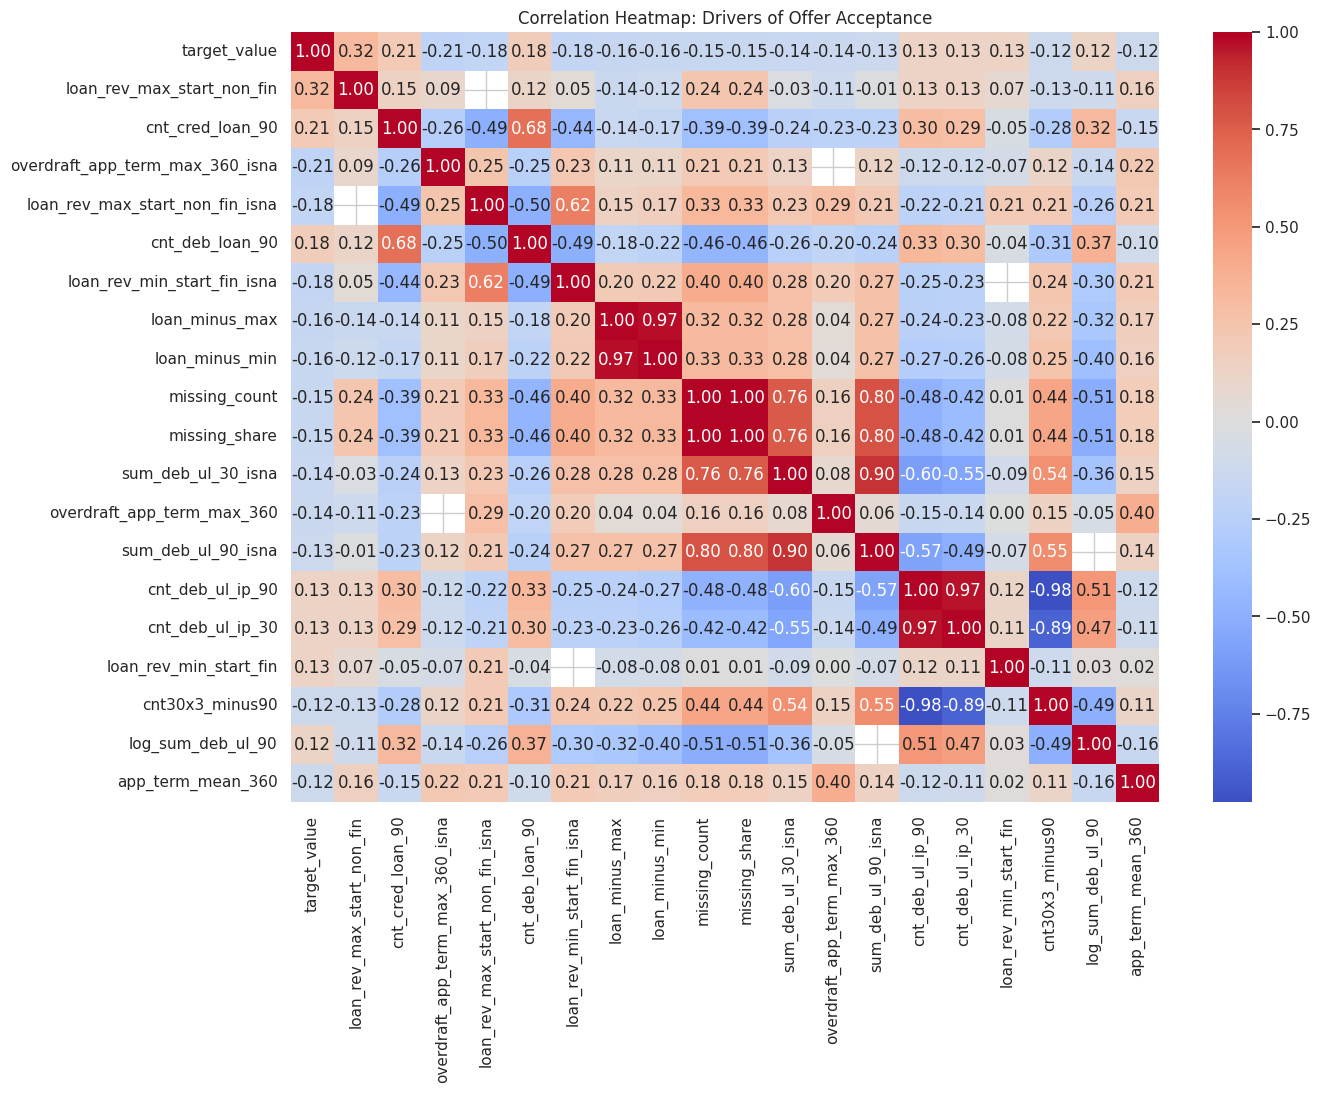

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Calculate Correlation with Target
corr_all = train_model[num_cols + [TARGET]].corr()
target_corr = corr_all[TARGET].sort_values(ascending=False)

print("--- Top Drivers of Offer Acceptance (Positive) ---")
print(target_corr.head(10))
print("\n--- Top Inhibitors of Offer Acceptance (Negative) ---")
print(target_corr.tail(10))

# 2. Rank pairs corr -> redundancy
corr_abs = corr_all.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
pairs = upper.unstack().dropna().sort_values(ascending=False)
feature_pairs = pairs[~pairs.index.get_level_values(0).isin([TARGET])]
feature_pairs = feature_pairs[~feature_pairs.index.get_level_values(1).isin([TARGET])]

print("\n--- Top 10 Most Correlated Feature Pairs (Potential Redundancy) ---")
print(feature_pairs.head(10))

# 3. Most significant features
top_corr_features = target_corr.abs().sort_values(ascending=False).index[:20]
plt.figure(figsize=(14, 10))
sns.heatmap(train_model[top_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Drivers of Offer Acceptance')
plt.show()

In [49]:
train_raw.head()

,front_id,decision_day,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,cnt_deb_loan_90,cnt_deb_ul_ip_90,cnt_deb_ul_ip_30,balance_rur_amt_30_min,cnt_cred_loan_90,loan_rev_max_start_non_fin,loan_rev_min_start_fin,app_term_mean_360,overdraft_app_term_max_360,days_from_authperson_registration,fl_hdb_bki_total_active_products,corp_list,count_all_corp_dashboard_events,p75_time_spent_minutes,sum_deb_investment_90,db_group_last,fl_adminarea,target_value
0,127345,2024-02-01,1.339991,-1.847954,-1.586546,1.774424,-0.400695,NaN,NaN,NaN,NaN,NaN,NaN,-5.561599,NaN,NaN,NaN,1.767094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lombard,NaN,0
1,127209,2024-02-01,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,0.842771,NaN,NaN,0.000000,-4.466656,-0.736050,1.466815,0.000000,NaN,NaN,-0.504888,NaN,NaN,NaN,-0.862289,-3.400318,-0.780786,NaN,inn_scoring,NaN,0
2,272776,2024-02-01,2.185431,3.167063,2.369547,-0.709770,-0.400695,0.000000,0.834373,4.897257,0.000000,5.291707,0.872047,4.041974,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.168810,3.015012,0.554064,NaN,NaN,NaN,0
3,127210,2024-02-01,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,NaN,NaN,NaN,NaN,NaN,NaN,-3.322507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,164500,2024-02-01,0.845440,4.559196,3.467730,-2.484194,-0.400695,0.000000,-0.518122,-3.435251,2.999207,-1.373655,-0.118673,4.324315,6.729738,NaN,NaN,NaN,NaN,1.067447,NaN,1.022327,1.506380,0.190096,NaN,NaN,NaN,0


In [50]:
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

def make_features(df: pd.DataFrame, ref_min_date=None) -> pd.DataFrame:
    """Фичи без таргета: одну и ту же функцию применяю к train и test."""
    out = df.copy()
    dt = pd.to_datetime(out[DATE_COL])
    if ref_min_date is None:
        ref_min_date = dt.min()

    #даты
    out['day_ord'] = dt.map(pd.Timestamp.toordinal).astype('int32')
    out['days_from_start'] = (dt - ref_min_date).dt.days.astype('int32')
    out['month'] = dt.dt.month.astype('int16')
    out['year'] = dt.dt.year.astype('int16')
    out['dow'] = dt.dt.dayofweek.astype('int16')
    out['dom'] = dt.dt.day.astype('int16')
    out['week'] = dt.dt.isocalendar().week.astype('int16')
    out['quarter'] = dt.dt.quarter.astype('int16')
    out['is_month_start'] = dt.dt.is_month_start.astype('int8')
    out['is_month_end'] = dt.dt.is_month_end.astype('int8')

    eps = 1e-6

    #параметры оффера
    out['rate_minus_cb'] = out['offered_rate'] - out['cb_rate']
    out['rate_div_cb'] = (out['offered_rate'] + eps) / (out['cb_rate'] + eps)
    out['limit_mean'] = (out['overdraft_limit_min'] + out['overdraft_limit_max']) / 2
    out['limit_range'] = out['overdraft_limit_max'] - out['overdraft_limit_min']
    out['loan_to_min'] = out['loan_amount_last'] / (out['overdraft_limit_min'] + eps)
    out['loan_to_max'] = out['loan_amount_last'] / (out['overdraft_limit_max'] + eps)
    out['loan_to_mean_limit'] = out['loan_amount_last'] / (out['limit_mean'] + eps)
    out['min_to_max_limit'] = out['overdraft_limit_min'] / (out['overdraft_limit_max'] + eps)
    out['limit_range_rel'] = out['limit_range'] / (out['limit_mean'] + eps)
    out['loan_minus_min'] = out['loan_amount_last'] - out['overdraft_limit_min']
    out['loan_minus_max'] = out['loan_amount_last'] - out['overdraft_limit_max']
    out['loan_between_limits'] = (
        (out['loan_amount_last'] >= out['overdraft_limit_min']) &
        (out['loan_amount_last'] <= out['overdraft_limit_max'])
    ).astype('int8')
    out['rate_x_loan'] = out['offered_rate'] * out['loan_amount_last']
    out['rate_x_limit_mean'] = out['offered_rate'] * out['limit_mean']

    #активность за 30/90 дней
    out['sum30_to_90'] = out['sum_deb_ul_30'] / (out['sum_deb_ul_90'] + eps)
    out['cnt30_to_90'] = out['cnt_deb_ul_ip_30'] / (out['cnt_deb_ul_ip_90'] + eps)
    out['sum30x3_minus90'] = out['sum_deb_ul_30'] * 3 - out['sum_deb_ul_90']
    out['cnt30x3_minus90'] = out['cnt_deb_ul_ip_30'] * 3 - out['cnt_deb_ul_ip_90']

    for col in ['sum_deb_ul_90', 'sum_deb_ul_30', 'balance_rur_amt_30_min', 'sum_deb_investment_90']:
        out[f'{col}_to_loan'] = out[col] / (out['loan_amount_last'] + eps)
        out[f'{col}_to_limit'] = out[col] / (out['limit_mean'] + eps)

    out['dashboard_per_product'] = out['count_all_corp_dashboard_events'] / (out['corp_credit_products'] + 1)
    out['time_per_event'] = out['p75_time_spent_minutes'] / (out['count_all_corp_dashboard_events'] + 1)
    out['corp_total_events'] = out[['corp_credit_products', 'corp_list', 'count_all_corp_dashboard_events']].fillna(0).sum(axis=1)

    #пропуски тоже могут быть сигналом
    base_feature_cols = [c for c in df.columns if c not in [TARGET, ID_COL, DATE_COL]]
    out['missing_count'] = df[base_feature_cols].isna().sum(axis=1).astype('int16')
    out['missing_share'] = out['missing_count'] / max(1, len(base_feature_cols))
    for col in base_feature_cols:
        if df[col].isna().any():
            out[f'{col}_isna'] = df[col].isna().astype('int8')

    #логи для денежных признаков; signed_log1p нормально переживает отрицательные остатки
    for col in [
        'loan_amount_last', 'overdraft_limit_min', 'overdraft_limit_max',
        'sum_deb_ul_90', 'sum_deb_ul_30', 'balance_rur_amt_30_min',
        'sum_deb_investment_90', 'limit_mean', 'limit_range'
    ]:
        out[f'log_{col}'] = signed_log1p(out[col])

    return out

ref_min_date = train_raw[DATE_COL].min()
train_fe = make_features(train_raw, ref_min_date)
test_fe = make_features(test_raw, ref_min_date)

In [51]:
#категории и простая frequency encoding
cat_cols = ['db_group_last', 'fl_adminarea']

train_part = train_fe.drop(columns=[TARGET]).copy()
full = pd.concat([train_part, test_fe], axis=0, ignore_index=True)

for col in cat_cols:
    full[col] = full[col].astype('object').where(full[col].notna(), 'MISSING')
    freq = full[col].value_counts(dropna=False)
    full[f'{col}_freq'] = full[col].map(freq).astype('float32')
    full[col] = full[col].astype('category')

train_model = full.iloc[:len(train_fe)].copy()
test_model = full.iloc[len(train_fe):].copy()
train_model[TARGET] = train_fe[TARGET].values

features = [c for c in train_model.columns if c not in [TARGET, ID_COL, DATE_COL]]
num_cols = [c for c in features if str(train_model[c].dtype) != 'category']

#NaN бустинги обработают, а inf лучше убрать
train_model[num_cols] = train_model[num_cols].replace([np.inf, -np.inf], np.nan)
test_model[num_cols] = test_model[num_cols].replace([np.inf, -np.inf], np.nan)

print('n_features:', len(features))
print('categorical:', cat_cols)
display(train_model[features + [TARGET]].head())

n_features: 97
categorical: ['db_group_last', 'fl_adminarea']


,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,cnt_deb_loan_90,cnt_deb_ul_ip_90,cnt_deb_ul_ip_30,balance_rur_amt_30_min,cnt_cred_loan_90,loan_rev_max_start_non_fin,loan_rev_min_start_fin,app_term_mean_360,overdraft_app_term_max_360,days_from_authperson_registration,fl_hdb_bki_total_active_products,corp_list,count_all_corp_dashboard_events,p75_time_spent_minutes,sum_deb_investment_90,db_group_last,fl_adminarea,day_ord,days_from_start,month,year,dow,dom,week,quarter,is_month_start,is_month_end,rate_minus_cb,rate_div_cb,limit_mean,limit_range,loan_to_min,loan_to_max,loan_to_mean_limit,min_to_max_limit,limit_range_rel,loan_minus_min,loan_minus_max,loan_between_limits,rate_x_loan,rate_x_limit_mean,sum30_to_90,cnt30_to_90,sum30x3_minus90,cnt30x3_minus90,sum_deb_ul_90_to_loan,sum_deb_ul_90_to_limit,sum_deb_ul_30_to_loan,sum_deb_ul_30_to_limit,balance_rur_amt_30_min_to_loan,balance_rur_amt_30_min_to_limit,sum_deb_investment_90_to_loan,sum_deb_investment_90_to_limit,dashboard_per_product,time_per_event,corp_total_events,missing_count,missing_share,corp_credit_products_isna,sum_deb_ul_90_isna,sum_deb_ul_30_isna,cnt_deb_loan_90_isna,cnt_deb_ul_ip_90_isna,cnt_deb_ul_ip_30_isna,balance_rur_amt_30_min_isna,cnt_cred_loan_90_isna,loan_rev_max_start_non_fin_isna,loan_rev_min_start_fin_isna,app_term_mean_360_isna,overdraft_app_term_max_360_isna,days_from_authperson_registration_isna,fl_hdb_bki_total_active_products_isna,corp_list_isna,count_all_corp_dashboard_events_isna,p75_time_spent_minutes_isna,sum_deb_investment_90_isna,db_group_last_isna,fl_adminarea_isna,log_loan_amount_last,log_overdraft_limit_min,log_overdraft_limit_max,log_sum_deb_ul_90,log_sum_deb_ul_30,log_balance_rur_amt_30_min,log_sum_deb_investment_90,log_limit_mean,log_limit_range,db_group_last_freq,fl_adminarea_freq,target_value
0,1.339991,-1.847954,-1.586546,1.774424,-0.400695,NaN,NaN,NaN,NaN,NaN,NaN,-5.561599,NaN,NaN,NaN,1.767094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lombard,MISSING,738917,0,2,2024,3,1,5,1,1,0,2.175119,-4.428383,-1.717250,0.261408,-0.725122,-0.844597,-0.780312,1.164766,-0.152225,3.187945,2.926536,0,2.377712,-3.047129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.150472,3.238668,NaN,NaN,NaN,NaN,0.000000,17,0.68,1,1,1,1,1,1,0,1,1,1,0,1,1,1,1,1,1,1,0,1,0.850147,-1.046601,-0.950323,NaN,NaN,-1.881234,NaN,-0.999620,0.232229,1085.0,54824.0,0
1,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,0.842771,NaN,NaN,0.000000,-4.466656,-0.736050,1.466815,0.000000,NaN,NaN,-0.504888,NaN,NaN,NaN,-0.862289,-3.400318,-0.780786,NaN,inn_scoring,MISSING,738917,0,2,2024,3,1,5,1,1,0,2.175119,-4.428383,-2.887122,0.537585,0.889913,1.072627,0.972765,1.205317,-0.186201,0.347425,-0.190160,1,-4.983450,-5.122978,NaN,0.164788,NaN,2.258504,NaN,NaN,NaN,NaN,-0.522279,-0.508055,NaN,NaN,-1.845220,0.325285,-3.419836,9,0.36,0,1,1,0,0,0,0,0,1,1,0,1,1,1,0,0,0,1,0,1,-1.337233,-1.424532,-1.286012,NaN,NaN,0.902928,NaN,-1.357669,0.430213,72064.0,54824.0,0
2,2.185431,3.167063,2.369547,-0.709770,-0.400695,0.000000,0.834373,4.897257,0.000000,5.291707,0.872047,4.041974,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.168810,3.015012,0.554064,NaN,MISSING,MISSING,738917,0,2,2024,3,1,5,1,1,0,-0.309075,1.771350,2.768305,-0.797516,0.690050,0.922299,0.789447,1.336568,-0.288088,-0.981632,-0.184116,0,-1.551152,-1.964858,5.869378,0.164795,13.857398,-2.675567,0.381789,0.301402,2.240865,1.769045,1.849508,1.460089,NaN,NaN,3.015012,0.137998,4.183821,9,0.36,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,1,1,1,1.158588,1.427211,1.214778,0.606703,1.774487,1.617798,NaN,1.326625,-0.586406,65782.0,54824.0,0
3,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,NaN,NaN,NaN,NaN,NaN,NaN,-3.322507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MISSING,MISSING,738917,0,2,2024,3,1,5,1,1,0,2.175119,-4.428383,-2.386276,0.419348,0.565689,0.674676,0.615394,1.192662,-0.175733,1.127450,0.708102,0,-2.605741,-4.234265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.262519,1.392341,NaN,NaN,NaN,NaN,0.000000,19,0.76,1,1,1,1,1,1,0,1

In [52]:
valid_mask = train_raw[DATE_COL] >= pd.Timestamp(VALID_FROM)
y = train_model[TARGET].astype(int)

X_tr = train_model.loc[~valid_mask, features].copy()
y_tr = y.loc[~valid_mask]
X_val = train_model.loc[valid_mask, features].copy()
y_val = y.loc[valid_mask]

print('train part:', X_tr.shape, 'target mean:', y_tr.mean())
print('valid part:', X_val.shape, 'target mean:', y_val.mean())

train part: (127073, 97) target mean: 0.05725842625892204
valid part: (18168, 97) target mean: 0.08641567591369441


In [53]:
val_preds = []
test_preds = []
model_names = []

def add_model_prediction(name, pred_val, pred_test):
    auc = roc_auc_score(y_val, pred_val)
    print(f'{name}: valid ROC-AUC = {auc:.6f}')
    val_preds.append(pred_val)
    test_preds.append(pred_test)
    model_names.append(name)
    return auc

def rank_average(preds, weights=None):
    if weights is None:
        weights = np.ones(len(preds))
    weights = np.asarray(weights, dtype=float)
    out = np.zeros(len(preds[0]), dtype=float)
    for w, p in zip(weights, preds):
        out += w * rankdata(p) / len(p)
    return out / weights.sum()

In [54]:
if RUN_LIGHTGBM:
    from lightgbm import LGBMClassifier, early_stopping, log_evaluation

    lgb_params_list = [
        dict(num_leaves=15, min_child_samples=200, learning_rate=0.030, reg_alpha=0.05, reg_lambda=2.0),
        dict(num_leaves=15, min_child_samples=100, learning_rate=0.020, reg_alpha=0.05, reg_lambda=2.0),
        dict(num_leaves=31, min_child_samples=150, learning_rate=0.020, reg_alpha=0.10, reg_lambda=2.5),
    ]

    for i, seed in enumerate(LGB_SEEDS):
        params = lgb_params_list[i % len(lgb_params_list)].copy()
        clf = LGBMClassifier(
            objective='binary', metric='auc', boosting_type='gbdt',
            n_estimators=3000,
            subsample=0.90, subsample_freq=1,
            colsample_bytree=0.90,
            random_state=seed,
            n_jobs=-1,
            verbose=-1,
            **params
        )
        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric='auc',
            categorical_feature=cat_cols,
            callbacks=[early_stopping(120, verbose=False), log_evaluation(200)]
        )
        pred_val = clf.predict_proba(X_val)[:, 1]
        best_iter = clf.best_iteration_ or 500

        #потом переобучаюсь на всём train
        final_iter = int(best_iter * 1.15) + 25
        final_clf = LGBMClassifier(
            objective='binary', metric='auc', boosting_type='gbdt',
            n_estimators=final_iter,
            subsample=0.90, subsample_freq=1,
            colsample_bytree=0.90,
            random_state=seed,
            n_jobs=-1,
            verbose=-1,
            **params
        )
        final_clf.fit(train_model[features], y, categorical_feature=cat_cols)
        pred_test = final_clf.predict_proba(test_model[features])[:, 1]

        add_model_prediction(f'LightGBM_seed_{seed}_iter_{final_iter}', pred_val, pred_test)
        gc.collect()

[200]	valid_0's auc: 0.753085
[400]	valid_0's auc: 0.755158
LightGBM_seed_42_iter_429: valid ROC-AUC = 0.755713
[200]	valid_0's auc: 0.749764
[400]	valid_0's auc: 0.753638
LightGBM_seed_123_iter_556: valid ROC-AUC = 0.754670
[200]	valid_0's auc: 0.753573
[400]	valid_0's auc: 0.755397
LightGBM_seed_2025_iter_517: valid ROC-AUC = 0.755957
[200]	valid_0's auc: 0.753204
[400]	valid_0's auc: 0.755533
LightGBM_seed_777_iter_365: valid ROC-AUC = 0.756281
[200]	valid_0's auc: 0.751282
[400]	valid_0's auc: 0.757043
LightGBM_seed_31415_iter_512: valid ROC-AUC = 0.757295


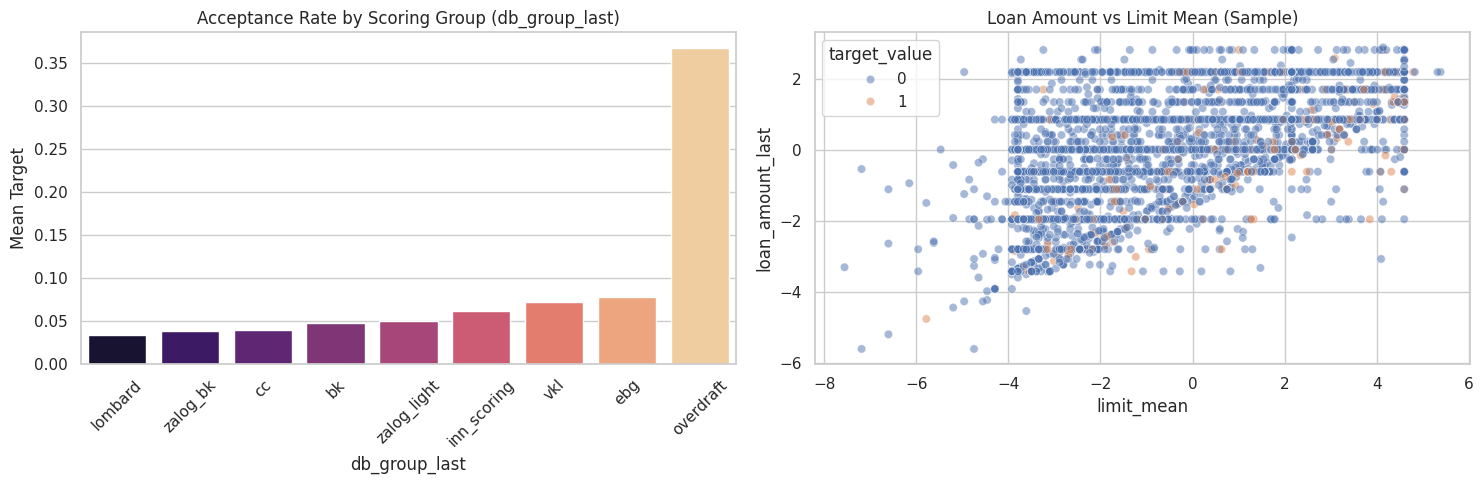

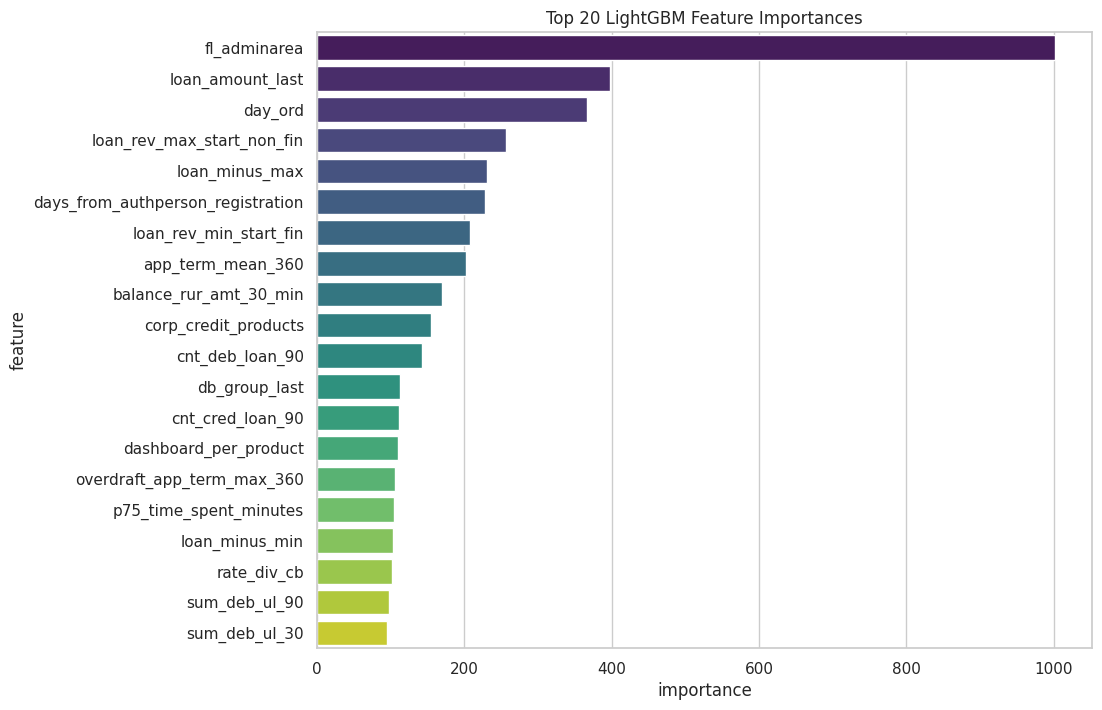

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
group_acceptance = train_raw.groupby('db_group_last')[TARGET].mean().sort_values()
sns.barplot(x=group_defaults.index, y=group_defaults.values, palette='magma')
plt.xticks(rotation=45)
plt.title('Acceptance Rate by Scoring Group (db_group_last)')
plt.ylabel('Mean Target')


# 2
if 'limit_mean' not in train_raw.columns:
    train_raw['limit_mean'] = (train_raw['overdraft_limit_min'] + train_raw['overdraft_limit_max']) / 2

plt.subplot(1, 2, 2)
sns.scatterplot(data=train_raw.sample(4000), x='limit_mean', y='loan_amount_last', hue=TARGET, alpha=0.5)
plt.title('Loan Amount vs Limit Mean (Sample)')
plt.tight_layout()
plt.show()

# 3. Feature Importance
if RUN_LIGHTGBM and 'clf' in locals():
    feat_imp = pd.DataFrame({'feature': features, 'importance': clf.feature_importances_})
    feat_imp = feat_imp.sort_values(by='importance', ascending=False).head(20)
    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')
    plt.title('Top 20 LightGBM Feature Importances')
    plt.show()

In [58]:
if RUN_CATBOOST:
    from catboost import CatBoostClassifier, Pool

    #для CatBoost категории удобнее отдать строками
    def to_catboost_frame(df):
        z = df.copy()
        for c in cat_cols:
            z[c] = z[c].astype(str).fillna('MISSING')
        return z

    X_tr_cat = to_catboost_frame(X_tr)
    X_val_cat = to_catboost_frame(X_val)
    X_all_cat = to_catboost_frame(train_model[features])
    X_test_cat = to_catboost_frame(test_model[features])

    for seed in CAT_SEEDS:
        cat = CatBoostClassifier(
            loss_function='Logloss',
            eval_metric='AUC',
            iterations=2500,
            learning_rate=0.035,
            depth=6,
            l2_leaf_reg=6,
            random_strength=1.5,
            bootstrap_type='Bayesian',
            bagging_temperature=0.5,
            random_seed=seed,
            od_type='Iter',
            od_wait=150,
            allow_writing_files=False,
            verbose=200
        )
        cat.fit(
            Pool(X_tr_cat, y_tr, cat_features=cat_cols),
            eval_set=Pool(X_val_cat, y_val, cat_features=cat_cols),
            use_best_model=True
        )
        pred_val = cat.predict_proba(X_val_cat)[:, 1]
        best_iter = cat.get_best_iteration() or 800
        final_iter = int(best_iter * 1.15) + 25

        final_cat = CatBoostClassifier(
            loss_function='Logloss',
            eval_metric='AUC',
            iterations=final_iter,
            learning_rate=0.035,
            depth=6,
            l2_leaf_reg=6,
            random_strength=1.5,
            bootstrap_type='Bayesian',
            bagging_temperature=0.5,
            random_seed=seed,
            allow_writing_files=False,
            verbose=200
        )
        final_cat.fit(Pool(X_all_cat, y, cat_features=cat_cols))
        pred_test = final_cat.predict_proba(X_test_cat)[:, 1]

        add_model_prediction(f'CatBoost_seed_{seed}_iter_{final_iter}', pred_val, pred_test)
        gc.collect()

0:	test: 0.6514545	best: 0.6514545 (0)	total: 355ms	remaining: 14m 46s
200:	test: 0.7491721	best: 0.7491721 (200)	total: 41.2s	remaining: 7m 50s
400:	test: 0.7532795	best: 0.7532795 (400)	total: 1m 21s	remaining: 7m 6s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.7533238983
bestIteration = 404

Shrink model to first 405 iterations.
0:	total: 320ms	remaining: 2m 36s
200:	total: 45.5s	remaining: 1m 5s
400:	total: 1m 29s	remaining: 19.6s
488:	total: 1m 49s	remaining: 0us
CatBoost_seed_42_iter_489: valid ROC-AUC = 0.753324


In [59]:
if RUN_XGBOOST:
    from xgboost import XGBClassifier

    #XGBoost тоже оставляю с category dtype
    X_all_xgb = train_model[features].copy()
    X_test_xgb = test_model[features].copy()
    for c in cat_cols:
        X_all_xgb[c] = X_all_xgb[c].astype('category')
        X_test_xgb[c] = X_test_xgb[c].astype('category')
    X_tr_xgb = X_all_xgb.loc[~valid_mask]
    X_val_xgb = X_all_xgb.loc[valid_mask]

    for seed in XGB_SEEDS:
        xgb = XGBClassifier(
            objective='binary:logistic',
            eval_metric='auc',
            tree_method='hist',
            enable_categorical=True,
            n_estimators=2000,
            learning_rate=0.025,
            max_depth=4,
            min_child_weight=10,
            subsample=0.90,
            colsample_bytree=0.90,
            reg_alpha=0.05,
            reg_lambda=2.0,
            random_state=seed,
            n_jobs=-1,
            early_stopping_rounds=120
        )
        xgb.fit(X_tr_xgb, y_tr, eval_set=[(X_val_xgb, y_val)], verbose=200)
        pred_val = xgb.predict_proba(X_val_xgb)[:, 1]
        best_iter = getattr(xgb, 'best_iteration', None) or 500
        final_iter = int(best_iter * 1.15) + 25

        final_xgb = XGBClassifier(
            objective='binary:logistic',
            eval_metric='auc',
            tree_method='hist',
            enable_categorical=True,
            n_estimators=final_iter,
            learning_rate=0.025,
            max_depth=4,
            min_child_weight=10,
            subsample=0.90,
            colsample_bytree=0.90,
            reg_alpha=0.05,
            reg_lambda=2.0,
            random_state=seed,
            n_jobs=-1
        )
        final_xgb.fit(X_all_xgb, y, verbose=False)
        pred_test = final_xgb.predict_proba(X_test_xgb)[:, 1]

        add_model_prediction(f'XGBoost_seed_{seed}_iter_{final_iter}', pred_val, pred_test)
        gc.collect()

[0]	validation_0-auc:0.69865
[200]	validation_0-auc:0.75590
[400]	validation_0-auc:0.75754
[436]	validation_0-auc:0.75623
XGBoost_seed_42_iter_388: valid ROC-AUC = 0.759082


In [60]:
assert len(test_preds) > 0, 'Не обучена ни одна модель: включите RUN_LIGHTGBM/RUN_CATBOOST/RUN_XGBOOST.'

val_mean = np.mean(val_preds, axis=0)
test_mean = np.mean(test_preds, axis=0)
auc_mean = roc_auc_score(y_val, val_mean)

val_rank = rank_average(val_preds)
test_rank = rank_average(test_preds)
auc_rank = roc_auc_score(y_val, val_rank)

print()
print('Model list:')
for name, p in zip(model_names, val_preds):
    print(f'{name:35s} {roc_auc_score(y_val, p):.6f}')

print(f'blend mean valid AUC: {auc_mean:.6f}')
print(f'blend rank valid AUC: {auc_rank:.6f}')

if auc_rank >= auc_mean:
    final_test_pred = test_rank
    print('Using rank-average for submission')
else:
    final_test_pred = test_mean
    print('Using probability mean for submission')

final_test_pred = np.clip(final_test_pred, 0, 1)


Model list:
LightGBM_seed_42_iter_429           0.755713
LightGBM_seed_123_iter_556          0.754670
LightGBM_seed_2025_iter_517         0.755957
LightGBM_seed_777_iter_365          0.756281
LightGBM_seed_31415_iter_512        0.757295
CatBoost_seed_42_iter_489           0.753324
XGBoost_seed_42_iter_388            0.759082
blend mean valid AUC: 0.758210
blend rank valid AUC: 0.758012
Using probability mean for submission


In [61]:
submission = pd.DataFrame({
    ID_COL: test_raw[ID_COL].values,
    TARGET: final_test_pred
})

submission[TARGET] = submission[TARGET].clip(0, 1)

OUT_PATH = '/content/submission.csv'
submission.to_csv(OUT_PATH, index=False)

print('shape:', submission.shape)
print(submission.head())

from google.colab import files
files.download(OUT_PATH)

shape: (36311, 2)
   front_id  target_value
0    150378      0.068000
1    194170      0.044368
2    102106      0.009405
3    256199      0.029739
4    253573      0.027328


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>